In [5]:
import sys 
print(sys.executable)

c:\Users\91790\AppData\Local\Programs\Python\Python313\python.exe


In [6]:
print(sys.executable)

c:\Users\91790\AppData\Local\Programs\Python\Python313\python.exe


In [1]:
import sys
print(sys.executable)

c:\Users\91790\AppData\Local\Programs\Python\Python313\python.exe


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("All libraries imported successfully")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully


In [3]:
import pandas as pd


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("All libraries imported successfully")

All libraries imported successfully


In [6]:
import pandas as pd

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

print(nav.head())
print("\nColumns:")
print(nav.columns)

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639

Columns:
Index(['amfi_code', 'date', 'nav'], dtype='str')


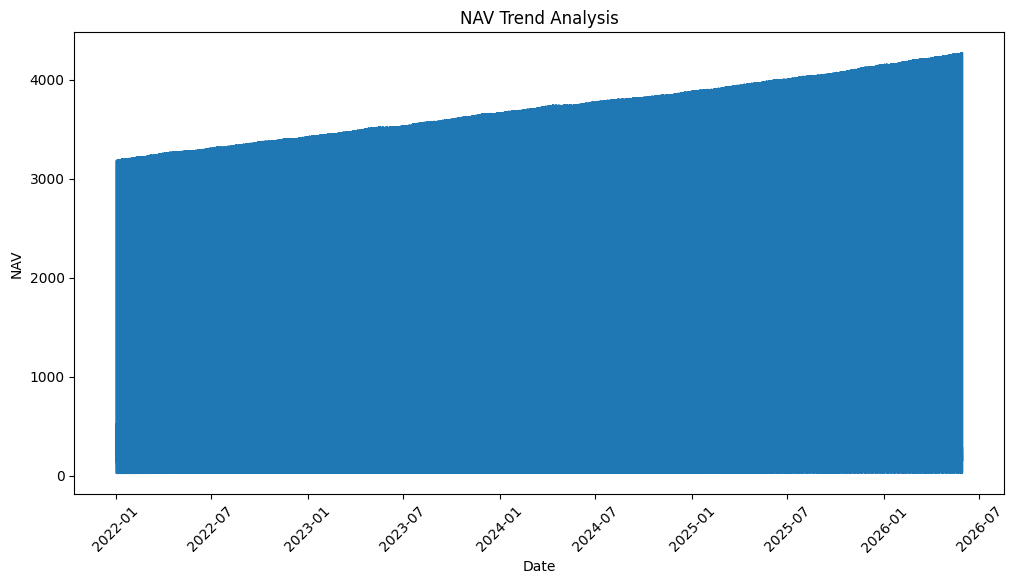

In [7]:
nav['date'] = pd.to_datetime(nav['date'])

nav_sorted = nav.sort_values('date')

plt.figure(figsize=(12,6))
plt.plot(nav_sorted['date'], nav_sorted['nav'])

plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.xticks(rotation=45)

plt.show()

Observation:
NAV shows an overall trend over the selected time period. Market fluctuations are visible at different intervals.

In [8]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.head())
print(aum.columns)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


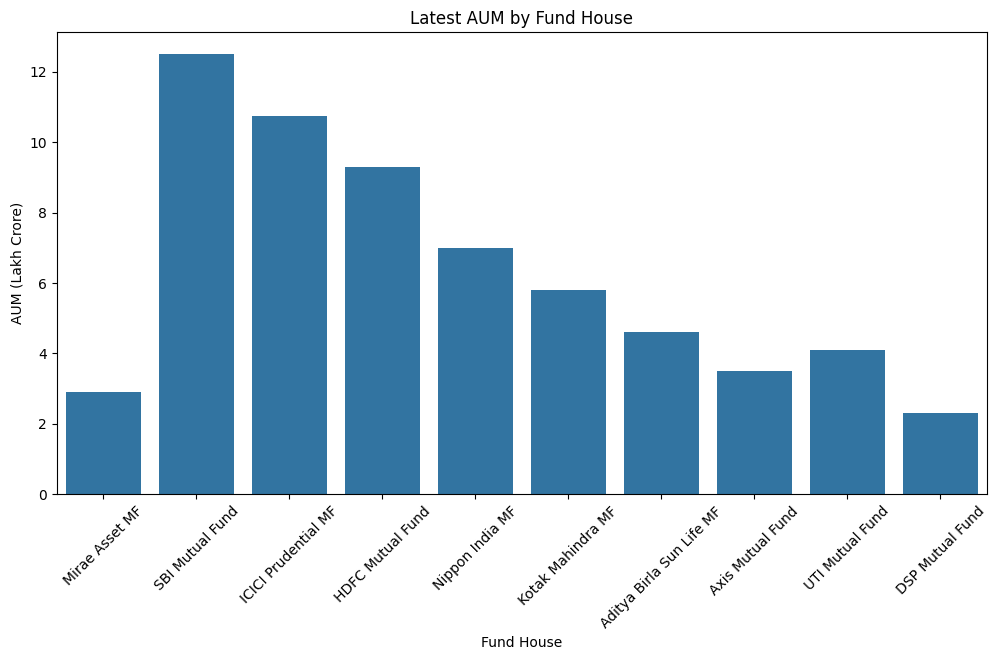

In [9]:
aum['date'] = pd.to_datetime(aum['date'])

latest_aum = aum.sort_values('date').groupby('fund_house').tail(1)

plt.figure(figsize=(12,6))
sns.barplot(
    data=latest_aum,
    x='fund_house',
    y='aum_lakh_crore'
)

plt.title("Latest AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)

plt.show()

Observation:
AUM varies significantly across fund houses. Some fund houses manage substantially larger assets than others.


In [10]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.head())
print(sip.columns)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


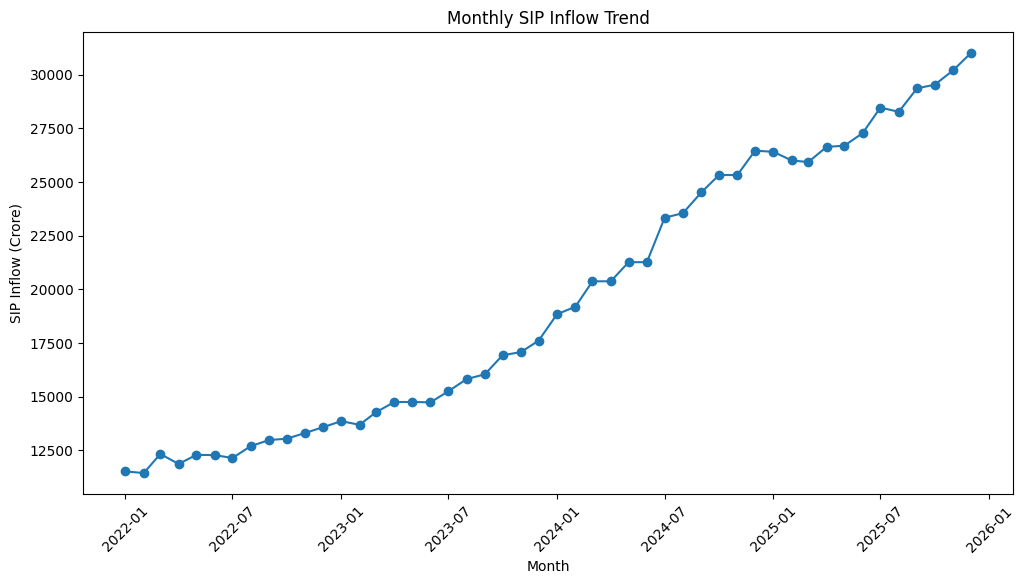

In [11]:
sip['month'] = pd.to_datetime(sip['month'])

sip = sip.sort_values('month')

plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    marker='o'
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.xticks(rotation=45)

plt.show()

Observation:
Monthly SIP inflows show the trend of retail investor participation. Changes in inflows indicate shifts in investor sentiment and market activity.

In [12]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.head())
print(category.columns)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
Index(['month', 'category', 'net_inflow_crore'], dtype='str')


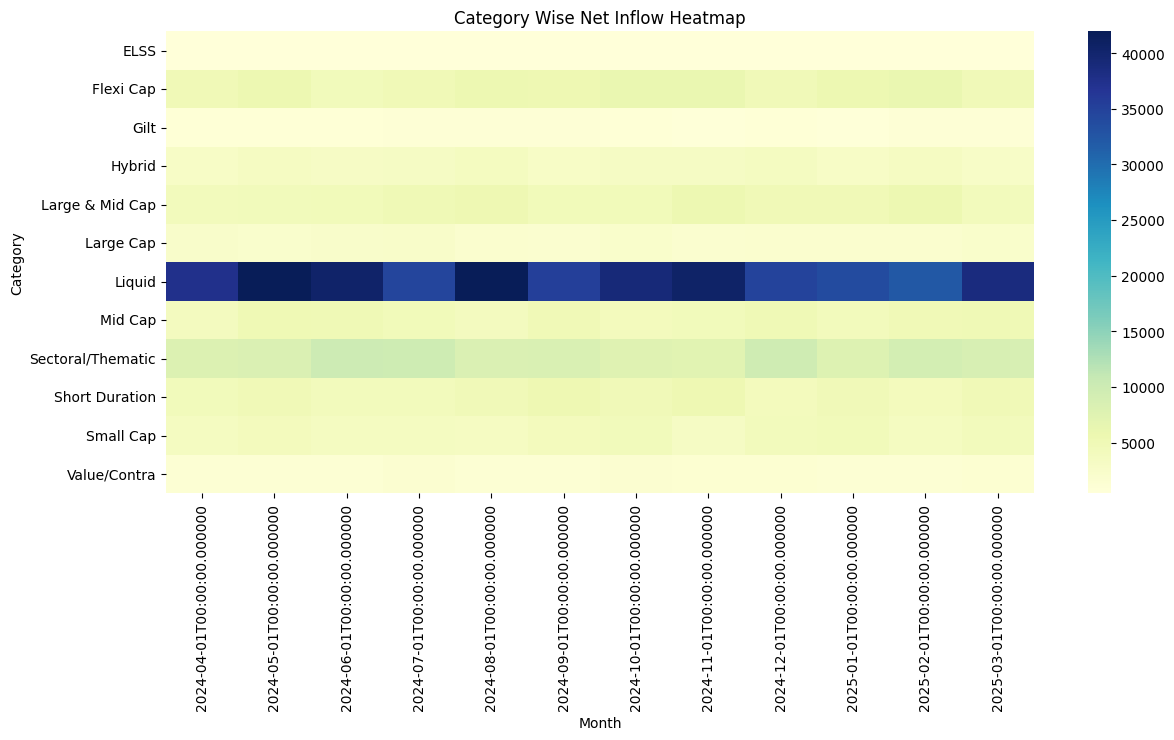

In [13]:
category['month'] = pd.to_datetime(category['month'])

heatmap_data = category.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore',
    aggfunc='sum'
)

plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data, cmap='YlGnBu')

plt.title("Category Wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

Observation:
Different mutual fund categories attract varying levels of inflows over time. The heatmap highlights periods of strong and weak investor interest across categories.

In [14]:
investor = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

print(investor.head())
print(investor.columns)

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              Sip        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              Sip         912   
3   INV003436       2024-01-01     118634              Sip        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

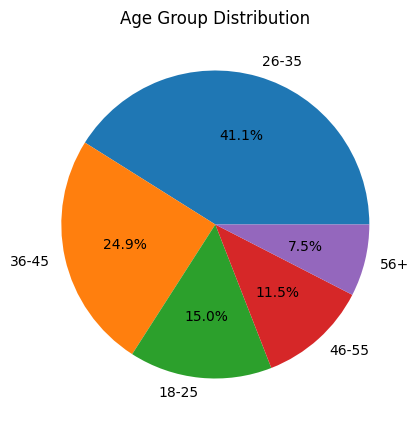

In [15]:
plt.figure(figsize=(8,5))

investor['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Age Group Distribution")
plt.ylabel("")

plt.show()

Observation:
The investor base is distributed across multiple age groups, with certain age segments contributing a larger share of participation.

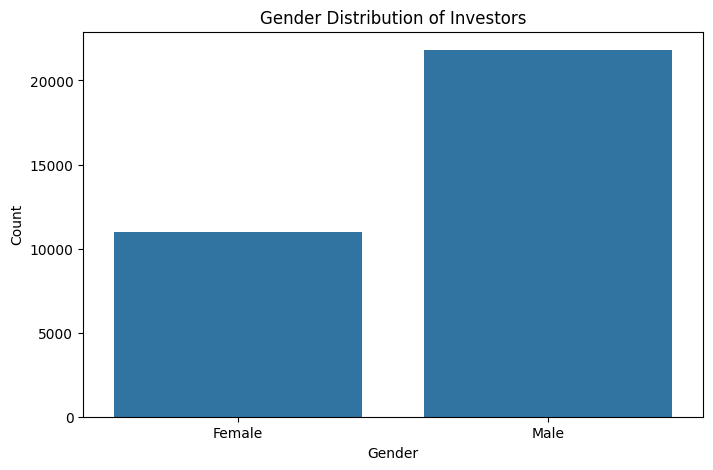

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=investor,
    x='gender'
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

Observation:
Gender participation shows the distribution of investors across different genders in the dataset.

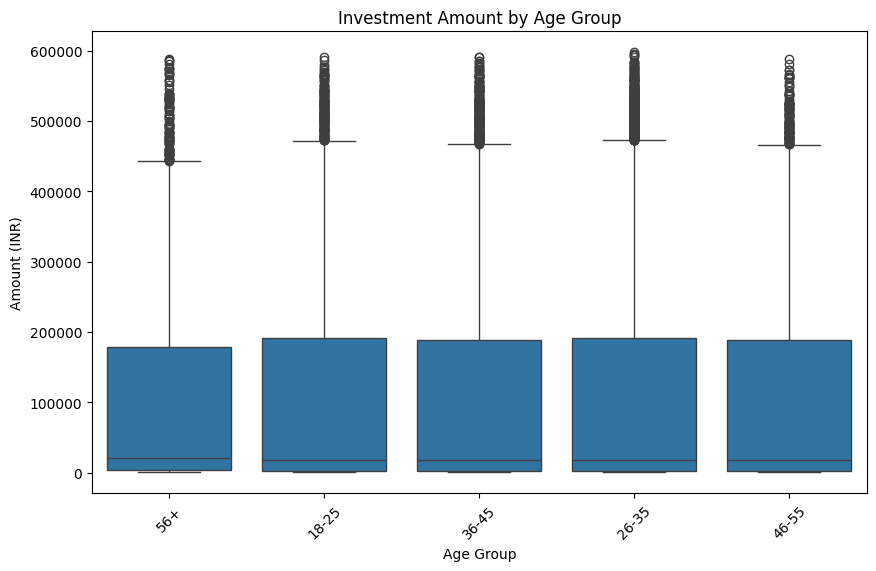

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x='age_group',
    y='amount_inr'
)

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.xticks(rotation=45)

plt.show()

Observation:
Investment amounts vary across age groups, indicating differences in investment capacity and behavior.

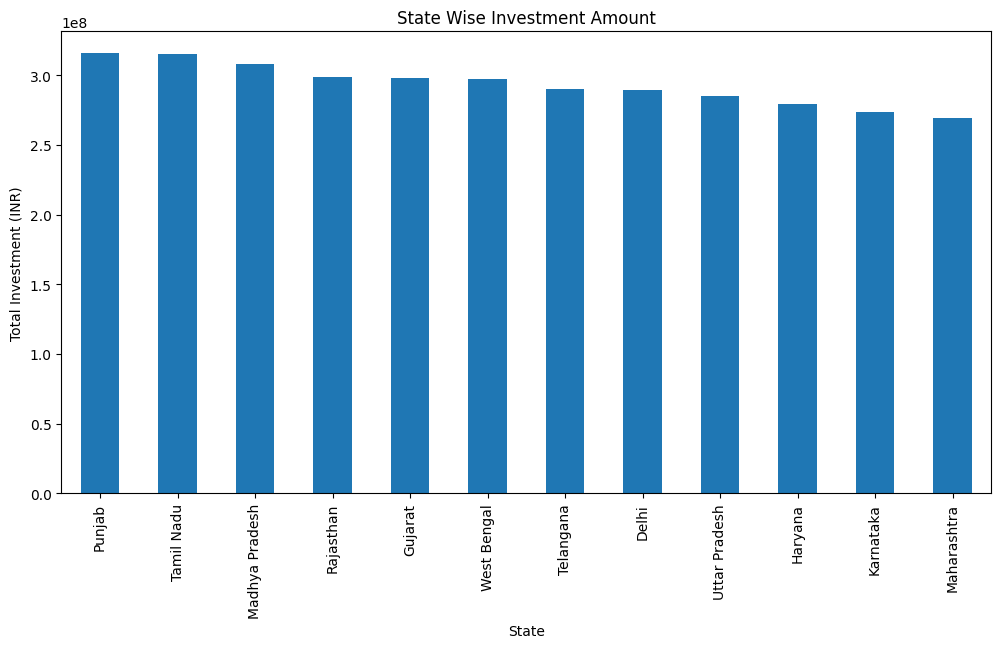

In [18]:
state_data = investor.groupby('state')['amount_inr'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

state_data.plot(kind='bar')

plt.title("State Wise Investment Amount")
plt.xlabel("State")
plt.ylabel("Total Investment (INR)")

plt.show()

Observation:
Certain states contribute significantly more investment volume than others.

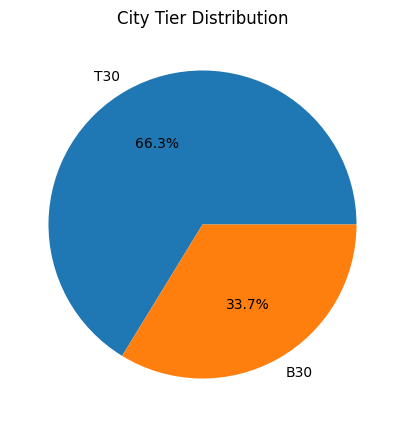

In [19]:
plt.figure(figsize=(8,5))

investor['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("City Tier Distribution")
plt.ylabel("")

plt.show()

Observation:
The distribution between T30 and B30 cities highlights the geographic spread of mutual fund participation.

In [20]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.head())
print(folio.columns)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


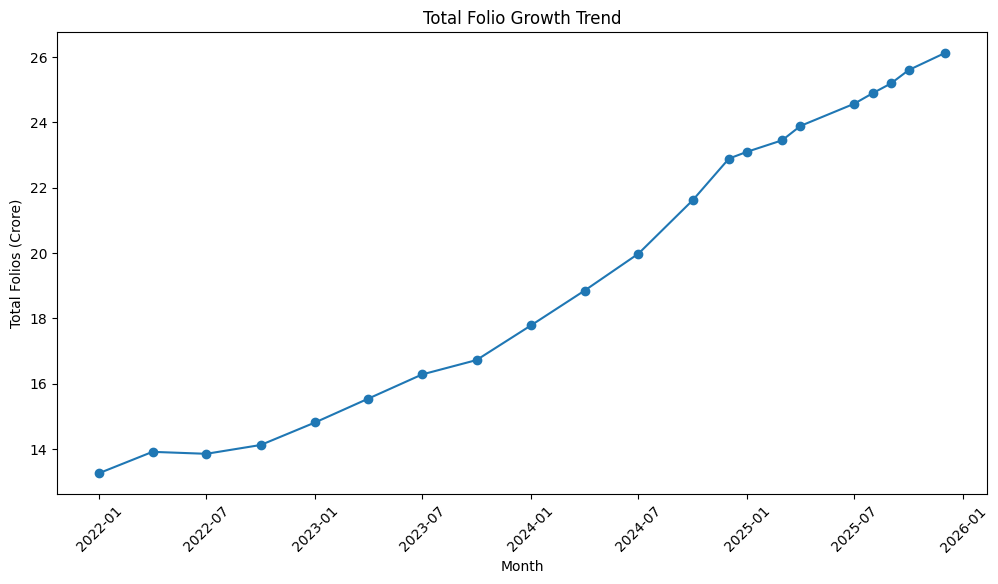

In [21]:
folio['month'] = pd.to_datetime(folio['month'])

folio = folio.sort_values('month')

plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.title("Total Folio Growth Trend")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)

plt.show()

Observation:
Total folio count shows the growth of mutual fund participation over time.

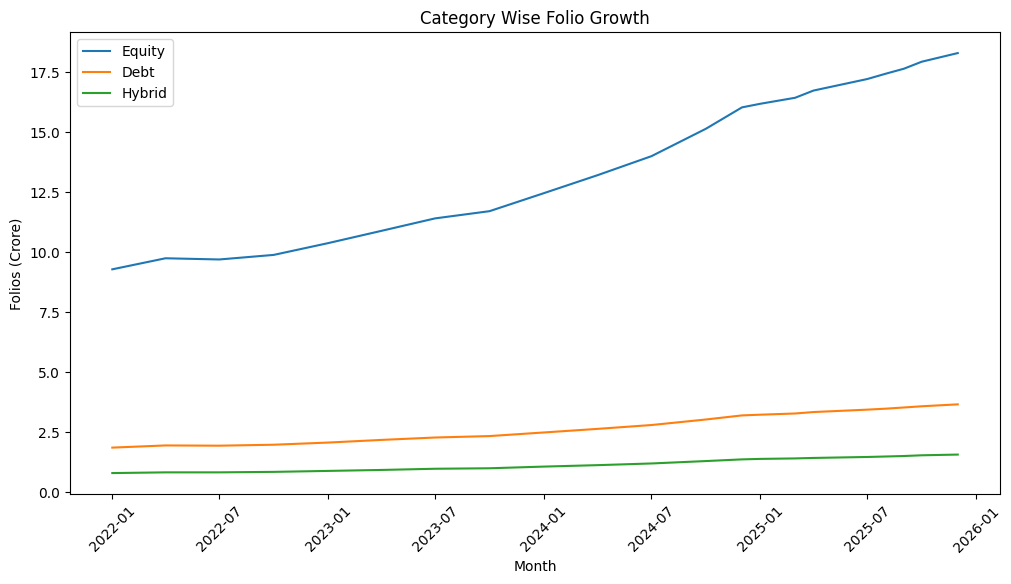

In [22]:
plt.figure(figsize=(12,6))

plt.plot(folio['month'], folio['equity_folios_crore'], label='Equity')
plt.plot(folio['month'], folio['debt_folios_crore'], label='Debt')
plt.plot(folio['month'], folio['hybrid_folios_crore'], label='Hybrid')

plt.title("Category Wise Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.legend()

plt.xticks(rotation=45)

plt.show()

Observation:
Equity, debt, and hybrid categories show different growth patterns across the analysis period.

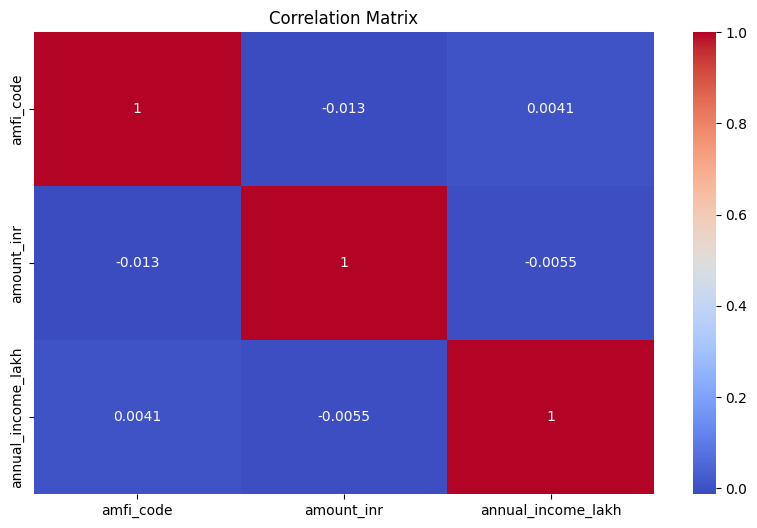

In [23]:
numeric_cols = investor.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

Observation:
The correlation matrix highlights relationships between numerical variables and helps identify patterns in investor behavior.

In [24]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(portfolio.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


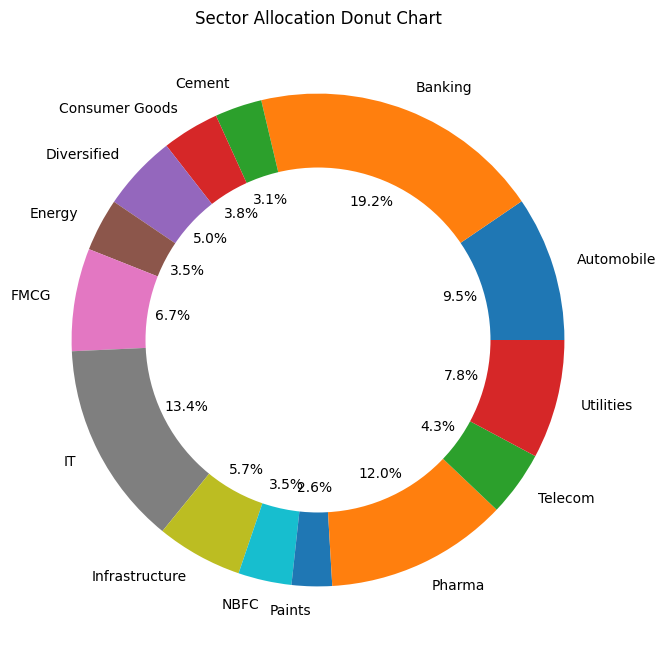

In [25]:
sector_data = portfolio.groupby('sector')['weight_pct'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Donut Chart")

plt.show()

Observation:
Portfolio allocation is concentrated across multiple sectors, showing diversification in mutual fund holdings.

1. NAV values show market-linked fluctuations over time.

2. AUM is concentrated among a few major fund houses.

3. SIP inflows show a long-term growth trend.

4. Investor participation varies across age groups.

5. Gender distribution highlights broad investor participation.

6. Investment amounts differ significantly across demographics.

7. Certain states contribute higher investment volumes.

8. Category-wise inflows vary across time periods.

9. Folio counts show increasing mutual fund adoption.

10. Portfolio allocation is diversified across sectors.